# Heart Disease - Feature Engineering, Model Development & Experiment Tracking

**MLOps Assignment 01 - Tasks 2, 3 & 4**

* **Task 2 - Feature Engineering & Model Development:** scaling + encoding
  pipeline, train Logistic Regression, Random Forest and XGBoost, tune with
  `GridSearchCV`, evaluate with cross-validation (accuracy, precision, recall,
  F1, ROC-AUC).
* **Task 3 - Experiment Tracking:** log params, metrics, plots and models to
  **MLflow**.
* **Task 4 - Model Packaging & Reproducibility:** persist the best sklearn
  **Pipeline** (preprocessing + model) with `joblib` + metadata JSON.

In [1]:
import sys, os, json
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = PROJECT_ROOT / "report" / "screenshots"; FIG_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load cleaned data & train/test split

In [2]:
from src.data_preprocessing import load_clean_data, split_features_target
from src.config import RANDOM_STATE, TEST_SIZE, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from sklearn.model_selection import train_test_split

df = load_clean_data(save=True)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Numeric:", NUMERIC_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Train: (242, 13)  Test: (61, 13)
Numeric: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 2. Feature engineering pipeline

A `ColumnTransformer` performs median-impute + `StandardScaler` on numeric
features and most-frequent-impute + `OneHotEncoder` on categorical clinical
codes. Wrapping it in a `Pipeline` with the estimator guarantees the identical
transformation is reused at inference time.

In [3]:
from src.data_preprocessing import build_preprocessor
pre = build_preprocessor()
pre  # display the transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 3. Model development, hyperparameter tuning & cross-validation

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from src.train import get_model_candidates
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
candidates = get_model_candidates()

def evaluate(pipe):
    yp = pipe.predict(X_test); pr = pipe.predict_proba(X_test)[:, 1]
    return {"accuracy": accuracy_score(y_test, yp),
            "precision": precision_score(y_test, yp, zero_division=0),
            "recall": recall_score(y_test, yp, zero_division=0),
            "f1": f1_score(y_test, yp, zero_division=0),
            "roc_auc": roc_auc_score(y_test, pr)}

fitted = {}
rows = []
for name, (est, grid) in candidates.items():
    pipe = Pipeline([("preprocessor", build_preprocessor()), ("model", est)])
    search = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    fitted[name] = best
    m = evaluate(best)
    m["cv_roc_auc"] = cross_val_score(best, X_train, y_train, scoring="roc_auc", cv=cv).mean()
    m["best_params"] = search.best_params_
    rows.append({"model": name, **m})
    print(f"{name}: best_params={search.best_params_}")

results_df = pd.DataFrame(rows).set_index("model")
results_df.drop(columns="best_params").round(4)

C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

logistic_regression: best_params={'model__C': 1.0, 'model__penalty': 'l2'}


random_forest: best_params={'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


xgboost: best_params={'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}


,accuracy,precision,recall,f1,roc_auc,cv_roc_auc
model,,,,,,
logistic_regression,0.8852,0.8387,0.9286,0.8814,0.9665,0.9025
random_forest,0.8852,0.8387,0.9286,0.8814,0.9545,0.8984
xgboost,0.9016,0.8667,0.9286,0.8966,0.9307,0.8703


## 4. Model comparison

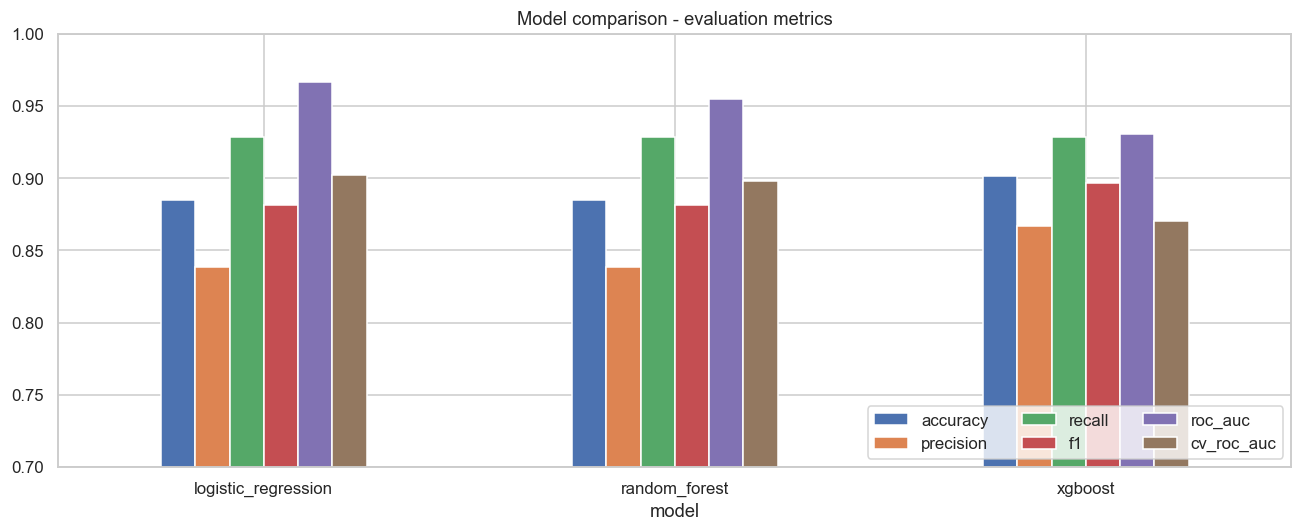

Best model by ROC-AUC: logistic_regression


In [5]:
metrics_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "cv_roc_auc"]
ax = results_df[metrics_cols].plot(kind="bar", figsize=(12, 5))
ax.set_title("Model comparison - evaluation metrics")
ax.set_ylim(0.7, 1.0); ax.legend(loc="lower right", ncol=3)
plt.xticks(rotation=0); plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison.png", bbox_inches="tight")
plt.show()

best_name = results_df["roc_auc"].idxmax()
print("Best model by ROC-AUC:", best_name)

## 5. Confusion matrix & ROC curve for the best model

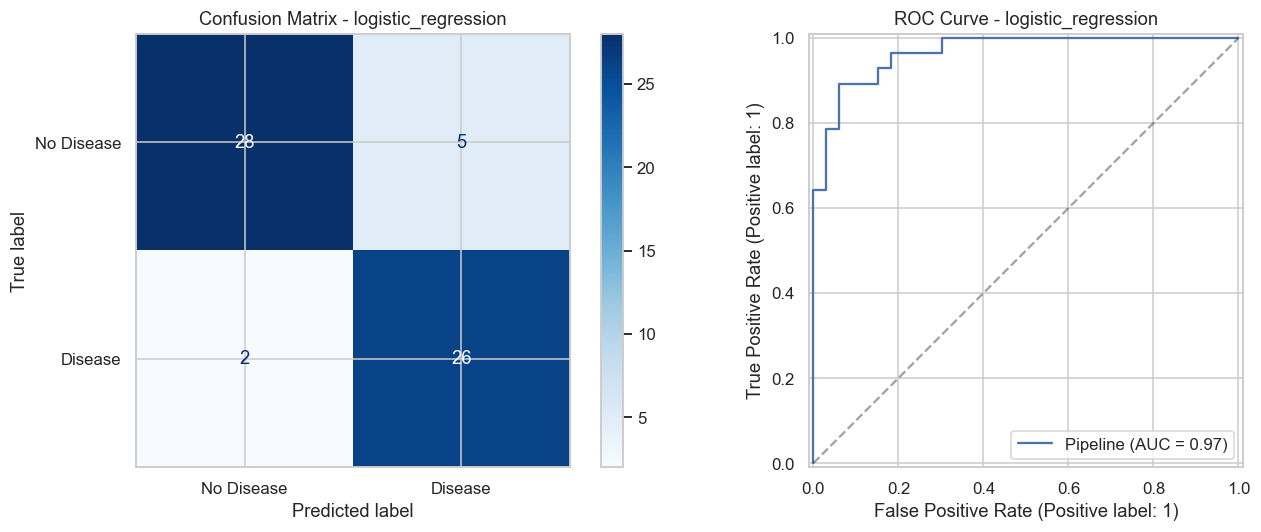

              precision    recall  f1-score   support

  No Disease       0.93      0.85      0.89        33
     Disease       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, classification_report
best_pipe = fitted[best_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(best_pipe, X_test, y_test,
    display_labels=["No Disease", "Disease"], cmap="Blues", ax=axes[0])
axes[0].set_title(f"Confusion Matrix - {best_name}")
RocCurveDisplay.from_estimator(best_pipe, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title(f"ROC Curve - {best_name}")
plt.tight_layout()
plt.savefig(FIG_DIR / "best_model_evaluation.png", bbox_inches="tight")
plt.show()

print(classification_report(y_test, best_pipe.predict(X_test),
                            target_names=["No Disease", "Disease"]))

## 6. Experiment tracking with MLflow

We log every run's parameters, metrics, ROC/confusion-matrix plots and the
serialized model. The full training routine lives in `src/train.py` so the CI
pipeline and this notebook share identical logic. Launch the UI afterwards with:

```bash
mlflow ui --backend-store-uri ./mlruns
```

In [7]:
from src.train import run_training
metadata = run_training(use_mlflow=True, verbose=True)
print("\nBest model selected:", metadata["best_model"])
json.dumps(metadata["metrics"], indent=2)


[train] === logistic_regression ===


C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\saqib\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l

[train] best params: {'model__C': 1.0, 'model__penalty': 'l2'}
[train] test metrics: {'accuracy': 0.8852459016393442, 'precision': 0.8387096774193549, 'recall': 0.9285714285714286, 'f1': 0.8813559322033898, 'roc_auc': 0.9664502164502166, 'cv_roc_auc': 0.9024931590148981}



[train] === random_forest ===


[train] best params: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
[train] test metrics: {'accuracy': 0.8852459016393442, 'precision': 0.8387096774193549, 'recall': 0.9285714285714286, 'f1': 0.8813559322033898, 'roc_auc': 0.9545454545454546, 'cv_roc_auc': 0.8983694244563811}



[train] === xgboost ===


[train] best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200}
[train] test metrics: {'accuracy': 0.9016393442622951, 'precision': 0.8666666666666667, 'recall': 0.9285714285714286, 'f1': 0.896551724137931, 'roc_auc': 0.9307359307359307, 'cv_roc_auc': 0.8702707115750595}



[train] Best model: logistic_regression (ROC-AUC=0.9665)
[train] Saved model -> C:\Users\saqib\heart-disease-mlops\models\heart_disease_model.joblib

Best model selected: logistic_regression


'{\n  "accuracy": 0.8852459016393442,\n  "precision": 0.8387096774193549,\n  "recall": 0.9285714285714286,\n  "f1": 0.8813559322033898,\n  "roc_auc": 0.9664502164502166,\n  "cv_roc_auc": 0.9024931590148981\n}'

## 7. Model packaging & reproducibility (Task 4)

`run_training` already persisted the winning **Pipeline** (preprocessing +
model) to `models/heart_disease_model.joblib` together with
`models/model_metadata.json`. Because preprocessing is embedded in the pipeline,
inference needs only the single joblib file - fully reproducible.

In [8]:
import joblib
from src.config import MODEL_PATH, METADATA_PATH
loaded = joblib.load(MODEL_PATH)
print("Reloaded pipeline steps:", [s[0] for s in loaded.steps])
print("Sanity prediction on first test row:", int(loaded.predict(X_test.iloc[[0]])[0]))
print("\nSaved metadata:")
print(json.loads(METADATA_PATH.read_text())["best_model"], "is the packaged model.")

Reloaded pipeline steps: ['preprocessor', 'model']
Sanity prediction on first test row: 0

Saved metadata:
logistic_regression is the packaged model.


## 8. Feature importance (interpretability)

For tree-based models we can inspect which clinical features drive predictions.

In [9]:
try:
    rf = fitted.get("random_forest")
    ohe_names = rf.named_steps["preprocessor"].get_feature_names_out()
    importances = rf.named_steps["model"].feature_importances_
    imp = pd.Series(importances, index=ohe_names).sort_values(ascending=False).head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    imp.iloc[::-1].plot(kind="barh", ax=ax, color="teal")
    ax.set_title("Top 15 feature importances (Random Forest)")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "feature_importance.png", bbox_inches="tight")
    plt.show()
except Exception as e:
    print("Feature importance skipped:", e)

C:\Users\saqib\AppData\Local\Temp\ipykernel_48564\4183701120.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
